In [1]:
import torch
import h5py
import re
import seaborn as sns
from collections import Counter
from os import listdir
from experiments_pretrained import *

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
chat_template_size = 18
n_experts = 60
n_layers = 24
k = 4
eam_data_dir = './eam_logs/'

In [3]:
filenames = listdir(eam_data_dir)
run_id = '20260224163242'
filenames = [eam_data_dir + f for f in filenames if run_id in f]

In [4]:
data = []
for filename in filenames:
    print(f"Loading from {filename}...")
    
    with h5py.File(filename, 'r') as f:
        n = int(re.split(r"-|\.", filename)[5][1:])
        
        for i in range(100):
            eam_str = f'eam_{i}'
            if eam_str in f:
                d = {
                    'eam': torch.tensor(f[eam_str][:]),
                    'prompt': f[eam_str].attrs['prompt'],
                    'response': f[eam_str].attrs['response'],
                    'subject': f[eam_str].attrs['subject'],
                    'prompt_tokenized': f[eam_str].attrs['prompt_tokenized'],
                    'response_tokenized': f[eam_str].attrs['response_tokenized'],
                }
                data.append(d)

Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n40.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n67.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n68.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n23.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n26.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n128.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n16.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n111.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n87.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n20.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n73.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n39.h5...
Loading from .

Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n102.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n116.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n107.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n121.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n51.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n50.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n113.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n74.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n45.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n117.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n35.h5...
Loading from ./eam_logs/qwen2moe-20260224163242-samples200000-tokens100-n41.h5...
Loading fr

In [5]:
# Count token occurances in output
tokenizer = load_tokenizer_qwen()

all_output_tokens = []
for d in data:
    #prompt_len = d['prompt_tokenized'].size + chat_template_size
    #print(prompt_len)
    output_tokens = list(d['response_tokenized'])
    all_output_tokens += output_tokens
    #eam = d['eam']
    #eam_output = eam[prompt_len:, :, :]
    
counts = Counter(all_output_tokens)

In [6]:
top_counts = counts.most_common()
top_ids = [t for (t, _) in top_counts]
top_strs = [tokenizer.decode(t) for t in top_ids]

In [7]:
per_id_activations = {}
eam_count = 0 
for d in data:
    output_tokens = list(d['response_tokenized'][:100])
    prompt_len = d['prompt_tokenized'].size + chat_template_size
    eam = d['eam']
    eam_output = eam[prompt_len:, :, :]
    #print(eam_output.size())
    _, topk_indices = torch.topk(eam_output, k, dim=-2)
    #print(f"output_tokens: {len(output_tokens)}, eam_output: {eam_output.size(0)}")
    #print(topk_indices.size())
    eam_count += 1
    #print(eam_count)
    for i in range(len(output_tokens)):
        t = output_tokens[i]
        if t in per_id_activations:
            per_id_activations[t].append(topk_indices[i,:,:])
        else:
            per_id_activations[t] = [topk_indices[i,:,:]]
    
for i in per_id_activations.keys():
    per_id_activations[i] = torch.cat(per_id_activations[i], dim=-2)

In [8]:
per_subject_activations = {}
eam_count = 0 
for d in data:
    output_tokens = list(d['response_tokenized'][:100])
    prompt_len = d['prompt_tokenized'].size + chat_template_size
    eam = d['eam']
    eam_output = eam[prompt_len:, :, :]
    subject = d['subject']
    #print(eam_output.size())
    _, topk_indices = torch.topk(eam_output, k, dim=-2)
    topk_indices = torch.flatten(topk_indices, start_dim=0, end_dim=1)
    #print(f"output_tokens: {len(output_tokens)}, eam_output: {eam_output.size(0)}")
    #print(topk_indices.size())
    #print(eam_count)
    if subject in per_subject_activations:
        per_subject_activations[subject].append(topk_indices)
    else:
        per_subject_activations[subject] = [topk_indices]
    
    
for s in per_subject_activations.keys():
    per_subject_activations[s] = torch.cat(per_subject_activations[s], dim=0)

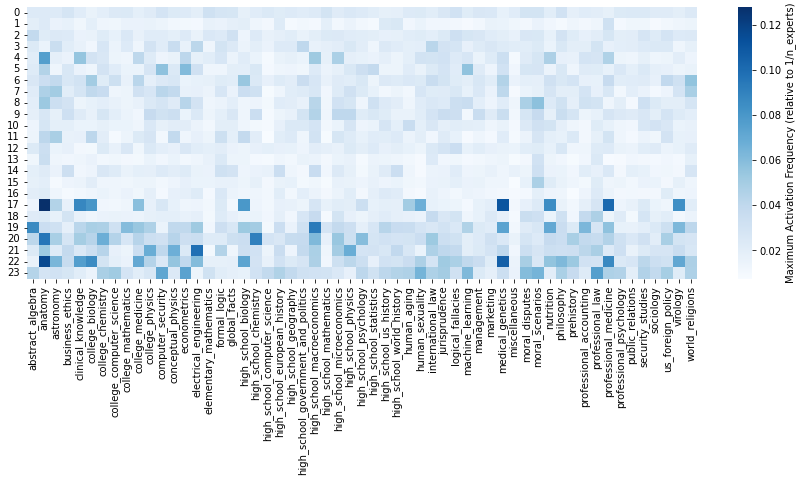

In [9]:
# Find subjects and layers with experts that are activated at a high frequency
subjects = sorted(list(per_subject_activations.keys()))
per_subject_counts = \
    {s: [Counter(per_subject_activations[s][:,l].tolist()) for l in range(n_layers)] \
     for s in subjects}

per_subject_freqs = \
    {s: [np.array([per_subject_counts[s][l][e] for e in range(n_experts)])/per_subject_counts[s][l].total() \
         for l in range(n_layers)] for s in subjects}
per_subject_max_freqs = {s: [max(per_subject_freqs[s][l]) for l in range(n_layers)]\
                        for s in subjects}

freq_relative = [[per_subject_max_freqs[s][l] - (1/n_experts) for s in subjects] for l in range(n_layers)]

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.heatmap(freq_relative, cmap="Blues", cbar=True, xticklabels=subjects, cbar_kws={'label': 'Maximum Activation Frequency (relative to 1/n_experts)'})
plt.show()

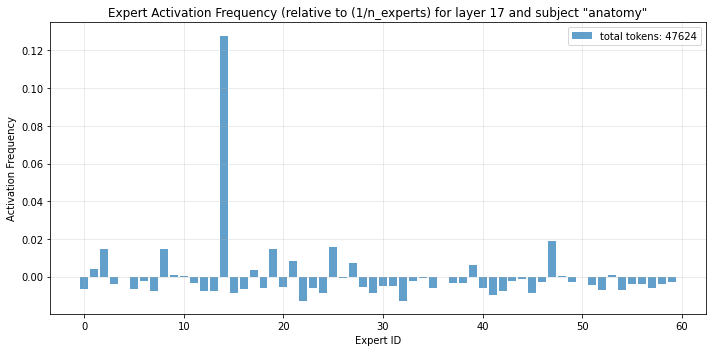

In [10]:
selected_subject = subjects[1]
selected_layer = 17

expert_counts = per_subject_counts[selected_subject][selected_layer]
expert_ids = np.array(sorted(expert_counts.keys()))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()
freqs = (count_per_expert / total) - (1/n_experts)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, freqs, \
        label='total tokens: %d' % (total), \
        alpha=0.7)

ax.set_title(f"Expert Activation Frequency (relative to (1/n_experts) for layer {selected_layer} and subject \"{selected_subject}\"")
ax.set_xlabel(f"Expert ID")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Find tokens which activate particular experts with high frequency
ids = sorted(list(per_id_activations.keys()))
per_id_counts = \
    {i: [Counter(per_id_activations[i][:,l].tolist()) for l in range(n_layers)] \
     for i in ids}

per_id_totals = {i: sum([per_id_counts[i][l].total() for l in range(n_layers)]) for i in ids}

per_id_freqs = \
    {i: [np.array([per_id_counts[i][l][e] for e in range(n_experts)])/per_id_counts[i][l].total() \
         for l in range(n_layers)] for i in ids}
per_id_max_freqs = {i: [max(per_id_freqs[i][l]) for l in range(n_layers)]\
                        for i in ids}

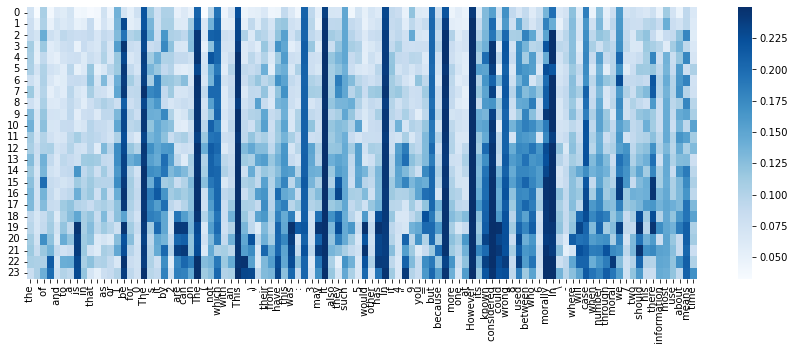

In [12]:
# Heatmap sorted by most common frequency
n_ids = 100
tokens = [tokenizer.decode(top_ids[i]) for i in range(n_ids)]
freq_mat = [[per_id_max_freqs[i][l] for i in top_ids[:n_ids]] for l in range(n_layers)]

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.heatmap(freq_mat, cmap="Blues", cbar=True, xticklabels=tokens)
plt.show()

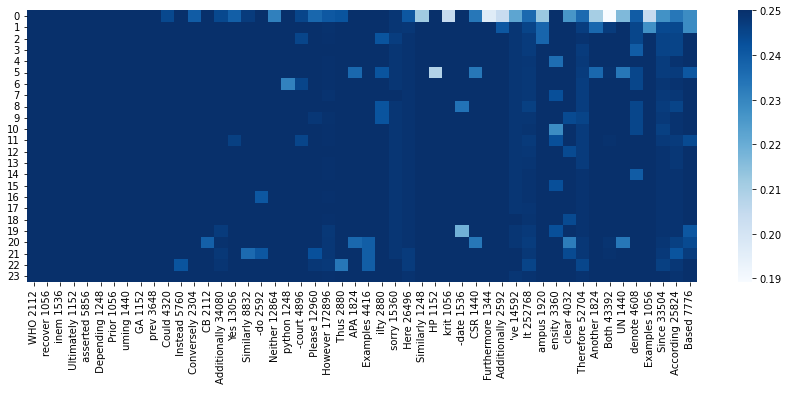

In [13]:
# Heatmap sorted by tokens with highest activation frequencies
per_id_avg_max_freqs = {i: np.mean(per_id_max_freqs[i]) for i in ids}
most_freq_ids = [i for freq, i in sorted(zip(per_id_avg_max_freqs.values(), per_id_avg_max_freqs.keys()), reverse=True)]

total_thresh = 1000
most_freq_ids_thresh = [i for i in most_freq_ids if per_id_totals[i] >= total_thresh]

n_ids = 50
tokens = [tokenizer.decode(most_freq_ids_thresh[i]) + f" {per_id_totals[most_freq_ids_thresh[i]]}" for i in range(n_ids)]
freq_mat = [[per_id_max_freqs[i][l] for i in most_freq_ids_thresh[:n_ids]] for l in range(n_layers)]

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.heatmap(freq_mat, cmap="Blues", cbar=True, xticklabels=tokens)
plt.show()

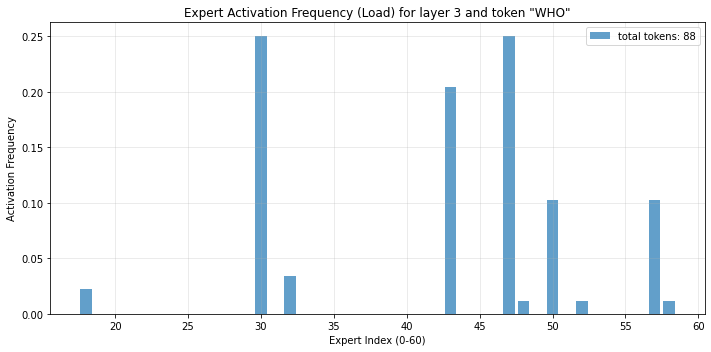

In [14]:
# Token routing histogram
selected_id = most_freq_ids_thresh[0]
selected_layer = 3

expert_counts = Counter(per_id_activations[selected_id][:,selected_layer].tolist())
expert_ids = np.array(sorted(expert_counts.keys()))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()
freqs = count_per_expert / total

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, freqs, \
        label='total tokens: %d' % (total), \
        alpha=0.7)

ax.set_title(f"Expert Activation Frequency (Load) for layer {selected_layer} and token \"{tokenizer.decode(selected_id)}\"")
ax.set_xlabel(f"Expert Index (0-{n_experts})")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

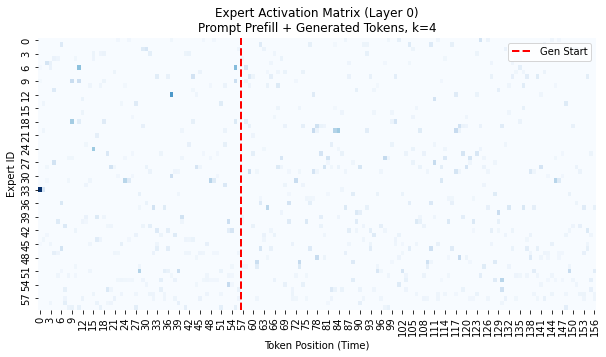

In [15]:
# Plot single EAM for a layer
selected_run = 0
selected_layer = 0

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
eam = data[selected_run]['eam']
eam = eam[:,:,selected_layer]
eam = torch.transpose(eam, 0, 1)

# Draw a line to separate prefill and decoding stages
prompt_len = data[selected_run]['prompt_tokenized'].size + chat_template_size
plt.axvline(x=prompt_len, color='red', linestyle='--', linewidth=2, label="Gen Start")

sns.heatmap(eam, cmap="Blues", cbar=False, cbar_kws={'label': 'Active'})
plt.title(f"Expert Activation Matrix (Layer {selected_layer})\nPrompt Prefill + Generated Tokens, k={k}")
plt.xlabel("Token Position (Time)")
plt.ylabel("Expert ID")
plt.legend()

Text(-3.0, 0.5, 'Expert ID')

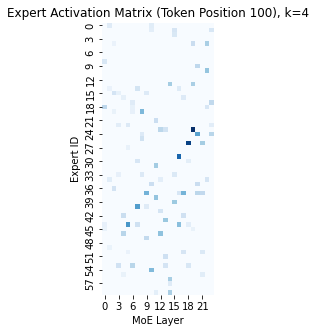

In [16]:
# Plot single EAM for an output token
selected_run = 0
selected_token_pos = 100

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
eam = data[selected_run]['eam']
eam = eam[selected_token_pos,:,:]

sns.heatmap(eam, cmap="Blues", cbar=False, cbar_kws={'label': 'Active'})
plt.title(f"Expert Activation Matrix (Token Position {selected_token_pos}), k={k}")
plt.xlabel("MoE Layer")
plt.ylabel("Expert ID")

Text(6.0, 0.5, 'Expert ID')

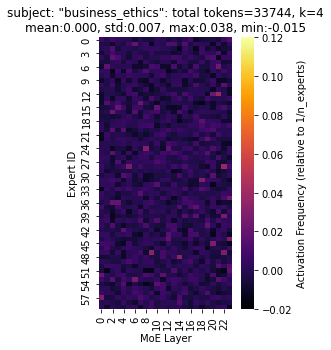

In [53]:
# Plot activations across layers for single subect
selected_subject =  subjects[3]

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = per_subject_counts[selected_subject]
n_tokens = counts[0].total()
eam = [[(counts[l][i]/n_tokens) - (1/n_experts) for l in range(n_layers)] for i in range(n_experts)]
outlier_thresh = 0.1
sd = np.std(np.array(eam)[(np.array(eam)<outlier_thresh)])
mean = np.mean(np.array(eam)[(np.array(eam)<outlier_thresh)])
max = np.max(eam)
min = np.min(eam)

sns.heatmap(eam, cmap="inferno", cbar=True, vmin=-0.02, vmax=0.12, cbar_kws={'label': 'Activation Frequency (relative to 1/n_experts)'})
plt.title(f"subject: \"{selected_subject}\": total tokens={n_tokens}, k={k}\nmean:{mean:.3f}, std:{sd:.3f}, max:{max:.3f}, min:{min:.3f}")
plt.xlabel("MoE Layer")
plt.ylabel("Expert ID")

In [18]:
selected_data = 0
selected_subject = 1
subject = subjects[selected_subject]
data_subject = [d for d in data if (d['subject'] == subject) and ('nerve impulses' in d['prompt'])]
print(data_subject[selected_data]['subject'])
print(data_subject[selected_data]['prompt'])
print(data_subject[selected_data]['response'])

anatomy
Which of the following is a substance that aids the transmission of nerve impulses to the muscles?
The substance that aids the transmission of nerve impulses to the muscles is called acetylcholine. Acetylcholine is a neurotransmitter, which means it is a chemical messenger that sends signals between neurons (nerve cells) in the nervous system. It is released by nerve cells and binds to receptors on the surface of muscle cells, triggering a response that causes the muscle to contract. Acetylcholine is the primary neurotransmitter involved in muscle contraction and is responsible for the contraction of all voluntary muscles
